In [15]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from timm import create_model
import random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler


In [16]:
from dotenv import load_dotenv
load_dotenv()
token = os.getenv("HF_TOKEN")
if token:
    print(f"Loaded token.")
else:
    print("Token not found.")

Loaded token.


In [17]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [18]:
def find_fg_indices(mask, axis):
	is_fg = mask.any(axis=axis)
	fg_indices = np.flatnonzero(is_fg)
	if fg_indices.size == 0:
		return None
	return fg_indices[0], fg_indices[-1]

class CropBackground:
	def __init__(self, threshold=5):
		self.threshold = threshold

	def __call__(self, img):
		arr = np.array(img)
		r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
		mask = (r > self.threshold) | (g > self.threshold) | (b > self.threshold)
		h, w = mask.shape
		row_bounds = find_fg_indices(mask, axis=1)
		col_bounds = find_fg_indices(mask, axis=0)
		rmin, rmax = row_bounds if row_bounds is not None else (0, h - 1)
		cmin, cmax = col_bounds if col_bounds is not None else (0, w - 1)
		return img.crop((cmin, rmin, cmax + 1, rmax + 1))



"First, we cropped out all backgrounds and resized the images to 512 × 512 pixels. (...) In our experiments, we applied translation,stretching, rotation, flipping, and colour augmentation "

In [19]:
img_size = 128

transform_train = transforms.Compose([
    #CropBackground(threshold=5),
    transforms.Resize((img_size, img_size)),
	transforms.RandomAffine(
		# translation,
        translate=(0.1, 0.1),
		# stretching,
		scale=(0.9, 1.1), 
		# rotation,
        degrees=15,
		
		fill=0
    ),
	# flipping, 
    transforms.RandomHorizontalFlip(),
	# and colour augmentation
    transforms.ColorJitter(brightness=0.5, contrast=1, saturation=0.1, hue=0.5),

    transforms.ToTensor(),
])

transform_eval = transforms.Compose([
	#CropBackground(threshold=5),
	transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

In [43]:
import time
class DDR_Dataset(Dataset):
    def __init__(self, root, mode, transform=None, small=True, print_stats=False):
        if small:
            dir_name = mode + "512"
        else:
            dir_name = mode
        self.img_dir = os.path.join(root, dir_name)
        self.transform = transform
        self.data = []
        self.print_stats = print_stats

        labels_file = mode + ".txt"
        path = os.path.join(root, labels_file)
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                img_name, grade = line.split()
                self.data.append((img_name, int(grade)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        t0 = time.time()
        img_name, label = self.data[index]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        t1 = time.time()

        if self.transform:
            img = self.transform(img)
        t2 = time.time()
        if self.print_stats:
            print(f"load: {(t1-t0)*1000:.1f}ms, transform: {(t2-t1)*1000:.1f}ms")
        return img, label

In [44]:
root = "./ddr/DDR-dataset/DR_grading"
trainset = DDR_Dataset(root, "train", transform=transform_train)
valset = DDR_Dataset(root, "valid", transform=transform_eval)
testset = DDR_Dataset(root, "test", transform=transform_eval)

In [45]:
def get_dataloaders(seed=42):
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=4, worker_init_fn=seed_worker, generator=g, pin_memory=True)
    valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    return trainloader,valloader, testloader

In [46]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [47]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [78]:
def diff_evaluate(model, loader, criterion):
	model.eval()
	total_loss, correct = 0, 0
	correct_per_class = np.zeros(6)
	class_nums = np.zeros(6)
	with torch.no_grad():
		for images, labels in loader:
			images = images.to(device, non_blocking=True)
			labels = labels.to(device, non_blocking=True)
			outputs = model(images)
			total_loss += criterion(outputs, labels).item()
			preds = outputs.argmax(1)

			labels_np = labels.cpu().numpy()
			preds_np = preds.cpu().numpy()

			class_nums += np.bincount(labels_np, minlength=6)
			
			correct_mask = (preds_np == labels_np)
			correct_per_class += np.bincount(labels_np[correct_mask], minlength=6)
			correct += (outputs.argmax(1) == labels).sum().item()
		# print(class_nums)
		per_class_acc = np.divide(
			correct_per_class, class_nums,
			out=np.zeros_like(correct_per_class), where=class_nums != 0
			)
		return total_loss / len(loader), correct / len(loader.dataset), per_class_acc

In [76]:
def execution_loop(model, optimizer, epochs, training_function, lr_scheduler, dataloader_function=get_dataloaders, print_stats=True, **kwargs):
  trainloader, valloader, testloader = dataloader_function(42)
  
  criterion = nn.CrossEntropyLoss()
  scaler = torch.amp.GradScaler('cuda')
  if print_stats:
    print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
    print("-" * 52)
  for epoch in range(epochs):
      current_lr = optimizer.param_groups[0]['lr']
      tr_loss, tr_acc = training_function(model, trainloader, optimizer, criterion, scaler, **kwargs)
      vl_loss, vl_acc = evaluate(model, valloader, criterion)
      if print_stats:
        print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {vl_loss:>8.4f}  {vl_acc:>7.7f}")
      lr_scheduler.step()
  test_loss, test_acc, test_acc_sep = diff_evaluate(model, testloader, criterion)
  print(f"\nTest metrics:  {test_loss:>8.4f}  {test_acc:>10.4f}")
  print(test_acc_sep)

In [36]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device = ", device)

device =  cuda


In [52]:
num_epochs = 2

set_seed(42)
import timm
convnext = create_model('convnext_tiny.fb_in22k', pretrained=True, num_classes=6)
convnext.to(device)
optim = torch.optim.Adam(convnext.parameters(), lr=1e-5)
scheduler = lr_scheduler.CosineAnnealingLR(optim, T_max=num_epochs, eta_min=1e-9)

execution_loop(convnext, optim, num_epochs, train_epoch, scheduler, print_stats=True)

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
    1      1.2652     0.4917    1.0304  0.5740944
    2      1.0512     0.5893    0.9238  0.6578851
[1880.  189. 1344.   71.  275.  346.]

Test metrics:    1.0063
[0.99574468 0.         0.16666667 0.         0.         0.85260116]


In [28]:
set_seed(42)
resnet = create_model('resnet18', pretrained=True, num_classes=6)
resnet.to(device)
r_optim = torch.optim.Adam(resnet.parameters(), lr=1e-5)
r_scheduler = lr_scheduler.CosineAnnealingLR(r_optim, T_max=num_epochs, eta_min=1e-9)

execution_loop(resnet, r_optim, num_epochs, train_epoch, r_scheduler, print_stats=True)

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
    1      1.7523     0.2379    1.7275  0.3691570
    2      1.6251     0.4088    1.5993  0.4790252
    3      1.5219     0.4759    1.5145  0.4926089
    4      1.4341     0.5008    1.4283  0.4978026
    5      1.3704     0.5027    1.3720  0.5045945
    6      1.3178     0.5128    1.3128  0.5189772
    7      1.2827     0.5145    1.2752  0.5185777
    8      1.2549     0.5080    1.2461  0.5249700
    9      1.2304     0.5212    1.2266  0.5313624
   10      1.2090     0.5273    1.2099  0.5345585
   11      1.1943     0.5256    1.1961  0.5353576
   12      1.1828     0.5305    1.1874  0.5457451
   13      1.1742     0.5358    1.1799  0.5453456
   14      1.1659     0.5329    1.1752  0.5457451
   15      1.1603     0.5380    1.1686  0.5461446
   16      1.1628     0.5326    1.1626  0.5493408
   17      1.1548     0.5431    1.1600  0.5521374
   18      1.1521     0.5425    1.1607  0.5569317

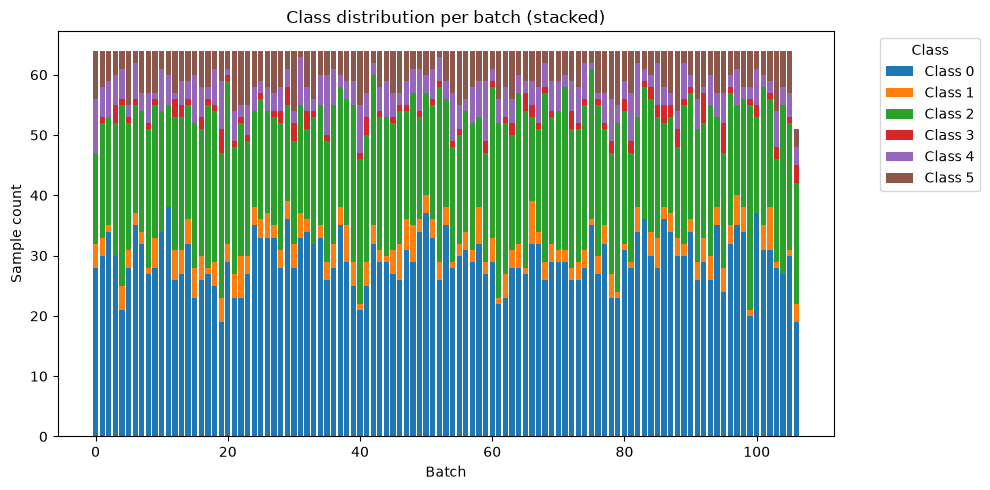

In [ ]:
import matplotlib.pyplot as plt
def see_distribution(trainloader):
  
  class_proportions = []
  for _, labels in trainloader:
    labels_cpu = labels.cpu().numpy()
    class_nums = np.bincount(labels_cpu, minlength=6)
    class_proportions.append(class_nums)

  data = np.array(class_proportions)          # shape: (num_batches, num_classes)
  num_batches, num_classes = data.shape
  batch_idx = np.arange(num_batches)

  # --- Option 1: Stacked bar chart (total batch size visible, class share within it) ---
  fig, ax = plt.subplots(figsize=(10, 5))
  bottom = np.zeros(num_batches)
  for c in range(num_classes):
      ax.bar(batch_idx, data[:, c], bottom=bottom, label=f'Class {c}')
      bottom += data[:, c]

  ax.set_xlabel('Batch')
  ax.set_ylabel('Sample count')
  ax.set_title('Class distribution per batch (stacked)')
  ax.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.tight_layout()
  plt.show()

      
    
trainloader, _, _ = get_dataloaders(42)
see_distribution(trainloader)


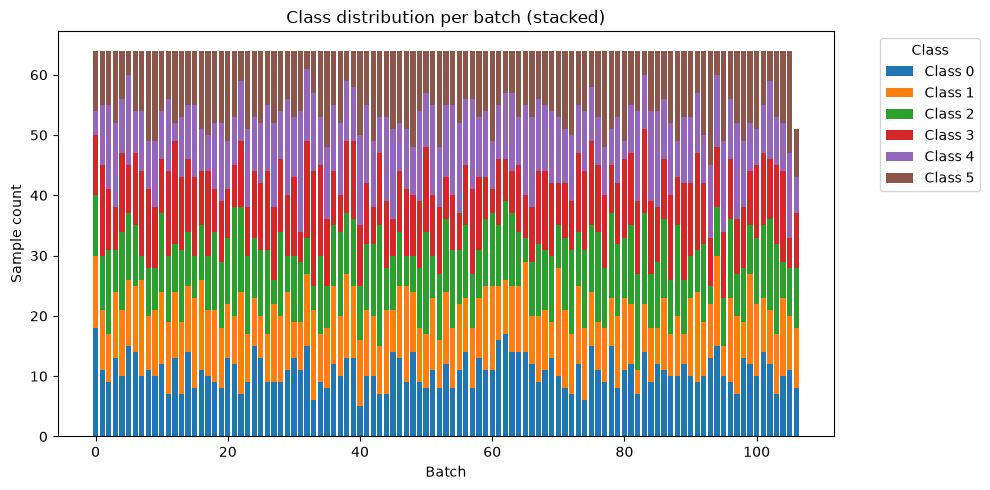

In [68]:
from torch.utils.data import WeightedRandomSampler

def get_resampled_dataloaders(seed=42):
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)
    #class_counts = imbalanced_train_df.label.value_counts(); class_counts
    labels_cpu = np.array([label for _, label in trainset.data])
    class_counts = np.bincount(labels_cpu, minlength=6)
    class_weights = 1/class_counts
    sample_weights = [1/class_counts[i] for i in labels_cpu]
    
    sampler= WeightedRandomSampler(weights=sample_weights, num_samples=len(labels_cpu), replacement=True)

    trainloader = DataLoader(trainset, batch_size=64, sampler=sampler, num_workers=4, worker_init_fn=seed_worker, generator=g, pin_memory=True)
    valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    return trainloader,valloader, testloader

a, _, _ = get_resampled_dataloaders()
see_distribution(a)

In [79]:
num_epochs = 7

set_seed(42)
import timm
convnext = create_model('convnext_tiny.fb_in22k', pretrained=True, num_classes=6)
convnext.to(device)
optim = torch.optim.Adam(convnext.parameters(), lr=1e-5)
scheduler = lr_scheduler.CosineAnnealingLR(optim, T_max=num_epochs, eta_min=1e-9)

execution_loop(convnext, optim, num_epochs, train_epoch, scheduler, get_resampled_dataloaders, print_stats=True)

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
    1      1.5988     0.3331    1.3021  0.5828760
    2      1.2709     0.4831    1.0858  0.5967801
    3      1.1364     0.5368    0.8568  0.7449689
    4      1.0729     0.5646    0.8672  0.7160629
    5      1.0176     0.5852    0.9278  0.6736187
    6      0.9848     0.5978    0.9102  0.6845957
    7      0.9847     0.6023    0.8819  0.6919136

Test metrics:    0.9274      0.6407
[0.95       0.03174603 0.21949405 0.71830986 0.61818182 0.93063584]
